In [6]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score

In [7]:
import joblib

In [8]:
df = pd.read_csv("creditcard.csv")
df.shape

(284807, 31)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [10]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


In [11]:
# Class distribution
print(df['Class'].value_counts())
# Check imbalance
print(df['Class'].value_counts(normalize=True))

Class
0    284315
1       492
Name: count, dtype: int64
Class
0    0.998273
1    0.001727
Name: proportion, dtype: float64


In [12]:
print(df.isnull().sum())

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64


In [13]:
#Time → seconds since first transaction

#V1–V28 → PCA components (already scaled)

#Amount → raw transaction value

#Class → target

#PCA features are already standardized, but Amount and Time are not.

In [14]:
scaler = StandardScaler()

df['Amount_scaled'] = scaler.fit_transform(df[['Amount']])
df['Time_scaled'] = scaler.fit_transform(df[['Time']])


In [15]:
df.drop(['Amount', 'Time'], axis=1, inplace=True)

In [16]:
#Add amount-based flags
#Add transaction intensity proxy

In [17]:
df['Amount_log'] = np.log1p(df['Amount_scaled'])

In [18]:
df['High_Amount'] = (df['Amount_scaled'] > 2).astype(int)

In [19]:
X = df.drop('Class', axis=1)
y = df['Class']

In [20]:
#sampling
fraud = df[df['Class'] == 1]
normal = df[df['Class'] == 0].sample(n=50000, random_state=42)
#shuffle 
df_sample = pd.concat([fraud, normal])

In [21]:
#shuffle 
df_sample = df_sample.sample(frac=1, random_state=42)

#train the model#split feature and target
X = df_sample.drop('Class', axis=1)
y = df_sample['Class']

#train the mode
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [22]:
#train model

In [23]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [24]:
#Predictions

In [25]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

In [26]:
#Model Evaluation

In [27]:
print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

print("\nClassification Report:\n", classification_report(y_test, y_pred))

print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))

print("ROC-AUC Score:", roc_auc_score(y_test, y_prob))

Accuracy: 0.9980196059015745

Confusion Matrix:
 [[9997    4]
 [  16   82]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     10001
           1       0.95      0.84      0.89        98

    accuracy                           1.00     10099
   macro avg       0.98      0.92      0.95     10099
weighted avg       1.00      1.00      1.00     10099

Precision: 0.9534883720930233
Recall: 0.8367346938775511
F1 Score: 0.8913043478260869
ROC-AUC Score: 0.9831751518725679


In [28]:
#Cross Validation

In [29]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_scores = cross_val_score(
    LogisticRegression(max_iter=1000),
    X, y,
    cv=skf,
    scoring='f1'
)

print("Cross-validation F1 scores:", cv_scores)
print("Mean F1 score:", cv_scores.mean())

Cross-validation F1 scores: [0.9197861  0.85393258 0.81818182 0.87640449 0.88043478]
Mean F1 score: 0.8697479551397768


In [30]:
#Final Prediction

In [31]:
# ----------- USING POSITION (iloc) -----------
pos = 10   # change this to any valid position (0 to len(X_test)-1)

sample_pos = X_test.iloc[[pos]]
pred_pos = model.predict(sample_pos)
actual_pos = y_test.iloc[pos]

print("=== Using iloc (Position) ===")
print("Position:", pos)
print("Prediction:", pred_pos[0])
print("Actual:", actual_pos)

if pred_pos[0] == actual_pos:
    print("✅ Correct Prediction")
else:
    print("❌ Wrong Prediction")


print("\n-----------------------------\n")


# ----------- USING INDEX (loc) -----------
idx = 77348   # your fraud index

if idx in X_test.index:
    sample_idx = X_test.loc[[idx]]
    pred_idx = model.predict(sample_idx)
    actual_idx = y_test.loc[idx]

    print("=== Using loc (Index) ===")
    print("Index:", idx)
    print("Prediction:", pred_idx[0])
    print("Actual:", actual_idx)

    if pred_idx[0] == actual_idx:
        print("✅ Correct Prediction")
    else:
        print("❌ Wrong Prediction")
else:
    print(f"Index {idx} not found in X_test (it's in training set)")

=== Using iloc (Position) ===
Position: 10
Prediction: 0
Actual: 0
✅ Correct Prediction

-----------------------------

Index 77348 not found in X_test (it's in training set)


In [32]:
#cross validation
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
pipeline = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('model', RandomForestClassifier(n_estimators=50, random_state=42))
])

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scores = cross_val_score(
    pipeline,
    X_train,
    y_train,
    cv=skf,
    scoring='f1'
)

print("CV F1 Scores:", scores)
print("Mean CV F1:", scores.mean())

CV F1 Scores: [0.88311688 0.87741935 0.85714286 0.90410959 0.88435374]
Mean CV F1: 0.8812284851272288


In [33]:
#handle imbalance using smote
smote = SMOTE(random_state=42)

X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print("Before SMOTE:\n", y_train.value_counts())
print("After SMOTE:\n", y_train_res.value_counts())

Before SMOTE:
 Class
0    39999
1      394
Name: count, dtype: int64
After SMOTE:
 Class
0    39999
1    39999
Name: count, dtype: int64


In [34]:
#logistic regression
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train_res, y_train_res)

lr_pred = lr_model.predict(X_test)
lr_prob = lr_model.predict_proba(X_test)[:, 1]

In [35]:
#random forest
rf_model = RandomForestClassifier(
    n_estimators=500,
    n_jobs=-1,
    class_weight = 'balanced',
    random_state=42
)
rf_model.fit(X_train_res, y_train_res)

,n_estimators,500
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [36]:
rf_pred = rf_model.predict(X_test)
rf_prob = rf_model.predict_proba(X_test)[:, 1]

In [37]:
#XGboost
from xgboost import XGBClassifier
ratio = (y_train == 0).sum() /( y_train == 1).sum()
xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    scale_pos_weight = ratio,
    n_jobs=-1,
    random_state=42
)

xgb_model.fit(X_train_res, y_train_res)

xgb_pred = xgb_model.predict(X_test)
xgb_prob = xgb_model.predict_proba(X_test)[:, 1]

In [38]:
#evaluvate all models together
from sklearn.metrics import classification_report, roc_auc_score

print("🔹 Logistic Regression")
print(classification_report(y_test, lr_pred))

print("🔹 Random Forest")
print(classification_report(y_test, rf_pred))

print("🔹 XGBoost")
print(classification_report(y_test, xgb_pred))

print("\nROC-AUC Scores:")
print("LR:", roc_auc_score(y_test, lr_prob))
print("RF:", roc_auc_score(y_test, rf_prob))
print("XGB:", roc_auc_score(y_test, xgb_prob))

🔹 Logistic Regression
              precision    recall  f1-score   support

           0       1.00      0.97      0.99     10001
           1       0.26      0.93      0.41        98

    accuracy                           0.97     10099
   macro avg       0.63      0.95      0.70     10099
weighted avg       0.99      0.97      0.98     10099

🔹 Random Forest
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     10001
           1       0.93      0.90      0.91        98

    accuracy                           1.00     10099
   macro avg       0.96      0.95      0.96     10099
weighted avg       1.00      1.00      1.00     10099

🔹 XGBoost
              precision    recall  f1-score   support

           0       1.00      0.93      0.97     10001
           1       0.12      0.93      0.21        98

    accuracy                           0.93     10099
   macro avg       0.56      0.93      0.59     10099
weighted avg       0.99   

In [39]:
#model comparison 

results = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest", "XGBoost"],
    "ROC-AUC": [
        roc_auc_score(y_test, lr_prob),
        roc_auc_score(y_test, rf_prob),
        roc_auc_score(y_test, xgb_prob)
    ]
})

print(results)

                 Model   ROC-AUC
0  Logistic Regression  0.980526
1        Random Forest  0.986935
2              XGBoost  0.975636


In [40]:
#tune threshold

In [41]:
threshold = 0.3

y_pred_custom = (lr_prob > threshold).astype(int)

from sklearn.metrics import recall_score

print("Recall after threshold tuning:", recall_score(y_test, y_pred_custom))

Recall after threshold tuning: 0.9387755102040817


In [42]:
#feature importance

In [43]:
feature_importance = pd.Series(
    rf_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print(feature_importance.head(10))

V14    0.182313
V12    0.123777
V10    0.111507
V4     0.102536
V17    0.087405
V11    0.063365
V3     0.042592
V16    0.040298
V7     0.026551
V2     0.021363
dtype: float64


In [44]:
#risk score
risk_score = model.predict_proba(X_test)[:,1]

In [45]:
#real time detection stimulator
def predict_transaction(transaction):
    prob = model.predict_proba(transaction)[0][1]
    
    if prob > 0.7:
        return prob, "⚠️ High Risk Fraud"
    elif prob > 0.3:
        return prob, "⚡ Medium Risk"
    else:
        return prob, "✅ Safe"

In [46]:
#alert 
prob, result = predict_transaction(X_test.iloc[[0]])
print("Risk score : ", prob)
print("Result : ",result)
if prob > 0.7:
    print("🚨 ALERT: Fraud Detected!")

Risk score :  0.00014442214028956185
Result :  ✅ Safe


In [47]:
#model comparision
results = pd.DataFrame({
    "Model": ["Logistic", "Random Forest", "XGBoost"],
    "ROC-AUC": [
        roc_auc_score(y_test, y_prob),
        roc_auc_score(y_test, rf_prob),
        roc_auc_score(y_test, xgb_prob)
    ]
})

print(results)

           Model   ROC-AUC
0       Logistic  0.983175
1  Random Forest  0.986935
2        XGBoost  0.975636


In [48]:
#choosing best model
final_model = rf_model

In [49]:
threshold = 0.3
y_pred_custom = (rf_prob > threshold).astype(int)
#improving the fraud detection

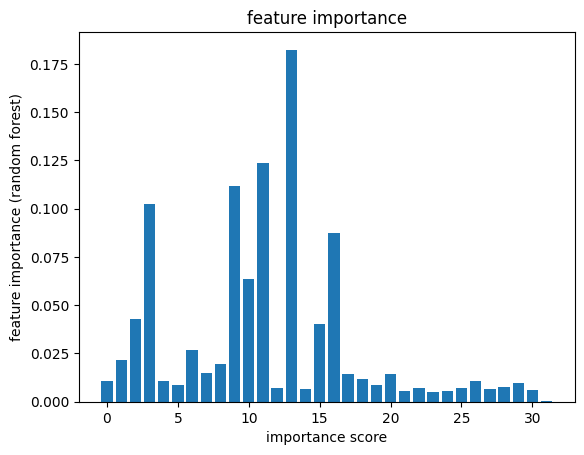

In [50]:
#plot 
import matplotlib.pyplot as plt

importances = rf_model.feature_importances_
plt.bar(range(len(importances)),importances)
plt.title("feature importance")
plt.xlabel("importance score")
plt.ylabel("feature importance (random forest)")
plt.show()

In [51]:
#confusion matrix
print(confusion_matrix(y_test,rf_pred))

[[9994    7]
 [  10   88]]


In [52]:
joblib.dump(rf_model,"fraud_model.pkl")
joblib.dump(X.columns,"columns.pkl")

['columns.pkl']